<a href="https://colab.research.google.com/github/gph05010/Daily-Study-Log-DeepLearning/blob/main/DeepLearning/ex07_Simple_RNN_%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 학습 목표
- RNN 개념
- Simple RNN을 이용한 학습

# RNN(Recurrent Neural Network)의 개요
- 문장, 소리, 동영상, 시계열 등은 <font color=red>이어지는 데이터(Sequential data)</font>로 구성되어 있기 때문에 그 의미를 전달하려면 각 단어가 정해진 순서대로 입력되어야 하므로 <font color=red>과거에 입력된 데이터와 나중에 입력된 데이터 사이의 관계를 고려</font>해야 함
- DNN, CNN는 지역적 특성을 추출하는 것이 목적이므로 시간적인 선후 관계를 분석하기는 어려움 → RNN 고안
  - CNN이 인간의 시각 인지 방식을 모델링한 기술이라면 RNN은 <font color=red>인간의 기억 방식</font>을 모델링한 기술
    - 인간의 기억은 시간이 지남에 따라 점차 현재에 미치는 영향이 감소한다는 조건

<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/rnn01.png" width=40%>   
</center>

- 여러 개의 데이터가 순서대로 입력되었을 때 이전 입력 데이터를 저장했다가 저장 데이터의 중요도를 판단하여 가중치를 계산하고 가중치를 이용해서 현재 학습에 반영

- RNN : 반복적이고 순차적인 데이터(Sequential data)학습에 특화된 인공신경망의 한 종류

<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/rnn02.png" width=40%>   
</center>

- 특징
  - 시간에 따른 순서를 기억
  - 이전 신경망의 출력이 다음 신경망과 연결되어 여러 개의 신경망으로 구성
  - <font color=red>시간적 변화의 특성</font>을 추출하여 학습 데이터로 사용

<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/rnn03.png" width=60%>   
</center>  

- x는 입력, Wxh는 입력 데이터에 곱해지는 가중치, Whh는 다음 층으로 전달되는 가중치, b는 편향
- 이전 층의 값이 tanh를 통과하여 영향력을 줄여가면서 다음 층으로 전달

<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/rnn09.png" width=60%>   
</center>  

- 활성화 함수로 tanh를 쓰는 이유
  - sigmoid보다 기울기를 더 유지 → 더 많은 시간동안 정보를 유지
   - 같은 레이어를 반복하므로 relu보다 효과적 → 1보다 큰 값이 들어오고 반복하면 값이 커짐 (기울기 발산) → 시간이 지남에 따라 멀리 떨어진 층의 영향력은 줄어야 하는데 relu는 그렇지 못함

<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/rnn05.png" width=40%>   
</center>     


- 단점
  - 처음 시작한 Weight의 값이 점차 학습이 될 수록 1보다 작은 값이 곱해져서 상쇄 → <font color=red>Gradient Vanishing</font>
    - 장기기억에 취약 : 시간이 지남에 따라 과거 데이터가 현재 데이터에 미치는  영향력이 감소
  - <font color=red>Gradient Exploding</font> : 시간에 따라 지속적으로 곱해지는 가중치가 지수적으로 증가하는 경우에 발생
    - 기울기 클리핑(Gradient clipping) : 특정 임계값을 넘는 기울기 값을 잘라내거나 특정 비율만큼 곱하여 기울기 값을 감소시키는 방법

<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/rnn04.png" width=40%>   
</center>      


# RNN 실습
 - 가장 간단한 rnn 모델을 사용해보자
 - 과거 4개의 알파벳을 기억해서 다음에 등장할 알파벳을 예측하는 모델을 생성해보자
   - h e l l > o
   - a p p l > e
   - hello, apple, hobby, below, wheel

<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/rnn10.png" width=50%>   
</center>


- 데이터 정의
  - 입력시킬 단어에 들어있는 알파벳을 원핫 인코딩으로 변환해서 전달
  

In [1]:
# h e l o a p b y w -> 9개의 알파벳 존재
# 크기가 9인 1차원 배열(벡터)로 표현

h = [1,0,0,0,0,0,0,0,0]
e = [0,1,0,0,0,0,0,0,0]
l = [0,0,1,0,0,0,0,0,0]
o = [0,0,0,1,0,0,0,0,0]
a = [0,0,0,0,1,0,0,0,0]
p = [0,0,0,0,0,1,0,0,0]
b = [0,0,0,0,0,0,1,0,0]
y = [0,0,0,0,0,0,0,1,0]
w = [0,0,0,0,0,0,0,0,1]

In [2]:
# hello, apple, hobby, below, wheel
# 끝에 글자를 제외한 입력 데이터(X)를 구성
import numpy as np

X_data = np.array(
    [[h,e,l,l],
     [a,p,p,l],
     [h,o,b,b],
     [b,e,l,o],
     [w,h,e,e]]
)

print(X_data)

[[[1 0 0 0 0 0 0 0 0]
  [0 1 0 0 0 0 0 0 0]
  [0 0 1 0 0 0 0 0 0]
  [0 0 1 0 0 0 0 0 0]]

 [[0 0 0 0 1 0 0 0 0]
  [0 0 0 0 0 1 0 0 0]
  [0 0 0 0 0 1 0 0 0]
  [0 0 1 0 0 0 0 0 0]]

 [[1 0 0 0 0 0 0 0 0]
  [0 0 0 1 0 0 0 0 0]
  [0 0 0 0 0 0 1 0 0]
  [0 0 0 0 0 0 1 0 0]]

 [[0 0 0 0 0 0 1 0 0]
  [0 1 0 0 0 0 0 0 0]
  [0 0 1 0 0 0 0 0 0]
  [0 0 0 1 0 0 0 0 0]]

 [[0 0 0 0 0 0 0 0 1]
  [1 0 0 0 0 0 0 0 0]
  [0 1 0 0 0 0 0 0 0]
  [0 1 0 0 0 0 0 0 0]]]


In [3]:
# 정답(y) 데이터 저장
# hello, apple, hobby, below, wheel -> 끝 글자에 해당하는 알파벳 저장
y_data = np.array([o, e, y, w, l])
y_data

array([[0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 1, 0, 0, 0, 0, 0, 0]])

- 입력 데이터
  - samples : 우리가 모델에게 순서를 가르쳐줄 단어 개수 = 5
  - timesteps : 한 번 예측을 위해 순서대로 확인할 데이터(알파벳)의 길이 = 4
  - Features : 각 타임스텝마다 들어가는 데이터의 크기 = 9

  **Simple RNN의 입력 데이터는 (samples, timesteps, features)**
  -> 3차원 구성. 중요!!

- 출력 데이터
  - simpleRNN은 2가지 모드로 출력
    1. 각 타임스텝의 출력을 모아서 반환 -> (samples, timesteps, output_features)
    2. 입력 시퀀스에 대한 마지막 출력만 반환 -> (samples, output_features)

### 모델 설계 및 학습
- RNN층 + MLP층

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, SimpleRNN

In [5]:
rnn_model = Sequential()

# 타임스텝 4번 동안, 한 번에 9개의 숫자로 이루어진 알파벳을 받음
rnn_model.add(InputLayer(shape = (4, 9)))

rnn_model.add(SimpleRNN(
    units=2,                # 매 시점마다 출력되는 과거 정보 요약본 벡터의 크기 설정
    activation="tanh",      # 활성화 함수
    return_sequences=False  # 출력 모양 설정, 전체 입력값에 해당하는 출력 1개만 받겠다
))

# 출력층
rnn_model.add(Dense(9, activation="softmax"))

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 2)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
# 학습 방법 설정
rnn_model.compile(
    loss="categorical_crossentropy", # 정답 데이터가 원핫 인코딩이 되어 있는 다중 분류
    optimizer="adam",
    metrics=["accuracy"]
)

In [7]:
h1 = rnn_model.fit(X_data, y_data, epochs=1000)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 2.5714
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.0000e+00 - loss: 2.5671
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.0000e+00 - loss: 2.5628
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.0000e+00 - loss: 2.5584
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.0000e+00 - loss: 2.5541
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0000e+00 - loss: 2.5498
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.0000e+00 - loss: 2.5456
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.0000e+00 - loss: 2.5413
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0000e+00 - loss: 2.5370
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.0000e+00 - loss: 2.5327
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0000e+00 - loss: 2.5285
Epoch 12/1000
1/1 ━━━

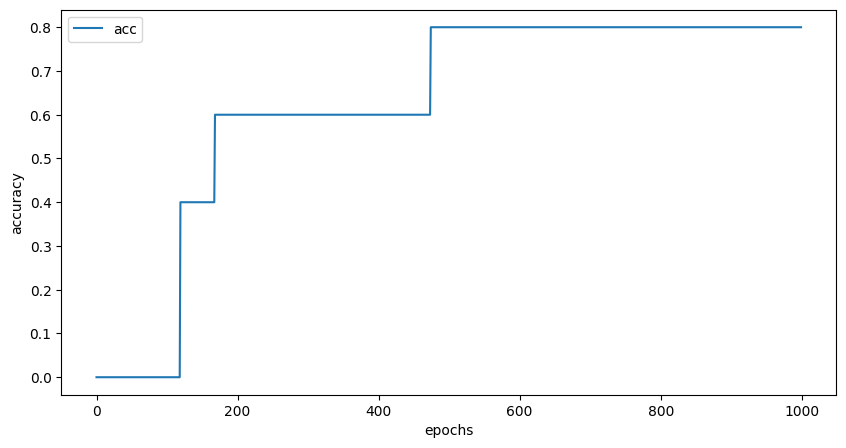

In [24]:
import matplotlib.pyplot as plt

# 학습 그래프 그리기
plt.figure(figsize=(10,5))
plt.plot(h1.history["accuracy"], label="acc")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()

- 예측

In [12]:
import pandas as pd


In [14]:
# 9개의 알파벳을 list에 담아서 저장
class_names = ['h', 'e', 'l', 'o', 'a', 'p', 'b', 'y', 'w']

# 테스트용 문제 데이터 정의
X_test = np.array([[w, h, e, e]])

# 예측
pred = rnn_model.predict(X_test)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


array([[0.02819765, 0.0522538 , 0.70291275, 0.0385319 , 0.03054846,
        0.03148442, 0.03023561, 0.06620184, 0.01963353]], dtype=float32)

In [15]:
pred_df = pd.DataFrame(pred, columns=class_names).T.sort_values(by=0, ascending=False)
display(pred_df)

,0
l,0.702913
y,0.066202
e,0.052254
o,0.038532
p,0.031484
a,0.030548
b,0.030236
h,0.028198
w,0.019634


In [16]:
# 확률값이 가장 큰 인덱스 저장
idx = np.argmax(pred)
class_names[idx] # 번호에 해당하는 알파벳 출력

'l'

- RNN의 목적은 시계열 데이터를 분류하는 것으로 학습은 오차역전파와 경사하강법을 사용
- RNN은 역전파의 확장판인 BPTT (Backpropagation Through Time)을 사용해 계수를 학습
- RNN의 구조가 시간에 따라 연결되어 있기 때문에 역전파는 끝까지 시간을 거슬러 올라가며 적용

<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/rnn14.png" width=60%>   
</center>

- RNN의 오차 역전파

<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/rnn16.png" width=40%>   
</center>

- 연쇄법칙

<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/rnn17.png" width=40%>   
</center>

<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/rnn18.png" width=40%>   
</center>

<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/rnn19.png" width=40%>   
</center>

- Truncated BPTT (단기 BPTT)
  - 시간 전체를 거슬러 올라가는 BPTT를 간략화 한 것
  - 시계열 데이터가 길어지면 은닉층에 저장해야 하는 양이 계속 늘어나기 때문에 모든 시간에 대한 은닉층의 값을 저장하는 것은 현실적으로 불가능하므로 적당한 선에서 타협
  - 단기 BPTT를 사용하면 기준 길이(보통 5 steps)보다 오래된 값은 반영하지 않으므로 장기간에 걸친 패턴이라면 RNN의 기억력이 짧아지는 문제가 있음

<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/rnn15.png" width=60%>   
</center>

# RNN의 고급 사용법
- dropout (입력 드롭아웃): 매 시점 새롭게 들어오는 현재 입력 데이터($x_t$) 중 일부를 0으로 만듭니다. 모델이 특정 단어 하나에만 의존해서 전체 문맥을 섣불리 판단하는 것을 막습니다.
- recurrent_dropout (순환 드롭아웃): 이전 시점에서 현재 시점으로 넘어오는 과거의 은닉 상태($h_{t-1}$) 중 일부를 0으로 만듭니다. 모델이 아주 오래전의 특정한 과거 정보 하나에만 집착하는 것을 막고, 문맥을 더 유연하게 파악하도록 강제합니다.
- <font color=red>순환 드롭아웃 (Recurrent dropout)</font> : LSTM/GRU 층에서 과대적합을 방지하기 위해 케라스에 내장되어 있는 Dropout을 사용
    - Keras에서 <font color=red>recurrent_dropout</font>  옵션으로 설정

<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/rnn32.png" width=40%>   
</center>     

- 입력 드롭아웃과 순환 드롭아웃

<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/rnn41.png" width=40%>   
</center>     

In [25]:
#
#
# rnn_model2
# input

# simple rnn 10, activation = tanh, sequences 출력 X

# 출력

rnn_model2 = Sequential()

# 타임스텝 4번 동안, 한 번에 9개의 숫자로 이루어진 알파벳을 받음
rnn_model2.add(InputLayer(shape = (4, 9)))

rnn_model2.add(SimpleRNN(
    units=10,                # 매 시점마다 출력되는 과거 정보 요약본 벡터의 크기 설정
    activation="tanh",       # 활성화 함수
    return_sequences=False,  # 출력 모양 설정, 전체 입력값에 해당하는 출력 1개만 받겠다
    dropout=0.2,             # 입력 드롭아웃 : 각 타임스텝에서 입력의 20%를 무작위로 0으로 만듦
    recurrent_dropout=0.3    # 순환 드롭아웃 : 이전 시점에서 전달받은 정보 중 30%를 무작위로 0으로 만듦
))

# 출력층
rnn_model2.add(Dense(9, activation="softmax"))

rnn_model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 10)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 299 (1.17 KB)

 Trainable params: 299 (1.17 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# 컴파일
# 학습 방법 설정
rnn_model2.compile(
    loss="categorical_crossentropy", # 정답 데이터가 원핫 인코딩이 되어 있는 다중 분류
    optimizer="adam",
    metrics=["accuracy"]
)

In [27]:
# 학습
h2 = rnn_model2.fit(X_data, y_data, epochs=1000)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 2.5185
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.0000e+00 - loss: 2.3191
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.0000e+00 - loss: 2.5662
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.0000e+00 - loss: 2.5828
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.0000e+00 - loss: 2.2079
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.0000e+00 - loss: 2.3332
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.0000e+00 - loss: 2.4398
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0000e+00 - loss: 2.3135
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0000e+00 - loss: 2.6394
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0000e+00 - loss: 2.4072
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0000e+00 - loss: 2.4962
Epoch 12/1000
1/1 ━━━

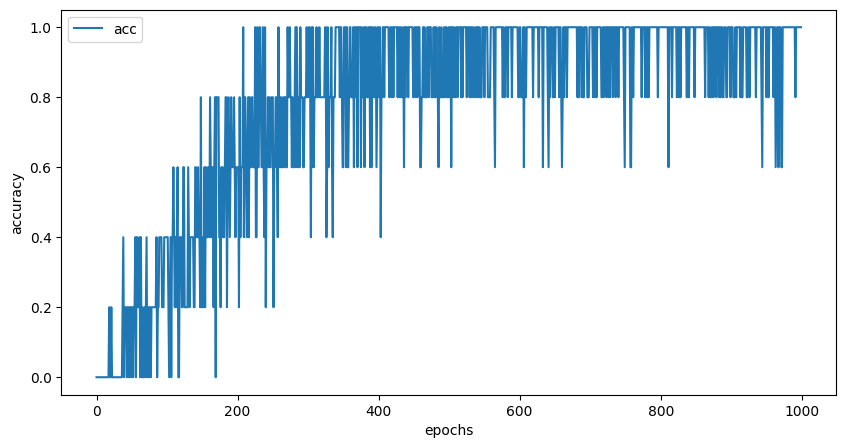

In [28]:
# 결과 그래프
plt.figure(figsize=(10,5))
plt.plot(h2.history["accuracy"], label="acc")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()
# 그래프 단톡방에 올리기

- <font colorp=red>스태킹 순환 층 (Stacking recurrent layer)</font> : RNN층을 여러 개 쌓는 것으로 네트워크의 표현 능력 향상 (계산 비용 상승)
  - 스태킹 순환층 사용시 모든 중간층에서는 전체 시퀀스(타임스텝)을 출력해야 함 (<font color=red>return_sequences= True</font>)
  - 일반적으로 스태킹 순환층을 많이 쌓기보다는 units값을 증가시키능 방법을 추천

<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/rnn33.png" width=50%>   
</center>   

In [30]:
from keras.models import Sequential
from keras.layers import Input, SimpleRNN, Dense

model = Sequential()

model.add(Input(shape=(10, 8)))

# 첫 번째 RNN 층 (시퀀스 전체를 다음 층에 넘김)
# return_sequences=True: 위층에 있는 두 번째 RNN도 시계열 데이터를 순서대로 받아야 하므로,
# 마지막 결과만 넘기지 않고 매 타임스텝의 연산 결과 10개를 모두 위로 올려보냅니다. (Many-to-Many 구조로 전달)
model.add(SimpleRNN(16, return_sequences=True))

# 두 번째 RNN 층 (마지막 출력만 반환)
# return_sequences=False (기본값): 전달받은 10개의 데이터를 다시 순서대로 처리한 후,
# 최종 예측을 위해 가장 마지막 시점의 결과물 딱 1개만 Dense 층으로 전달합니다.
model.add(SimpleRNN(8))

# 출력층
model.add(Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 10, 16)         │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 609 (2.38 KB)

 Trainable params: 609 (2.38 KB)

 Non-trainable params: 0 (0.00 B)

- <font color=red>양방향 순환 층 (Bidirectional recurrent layer)</font> : RNN에 같은 정보를 다른 방향으로 주입하여    정확도를 높이고 기억을 좀 더 오래 유지시킴

<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/rnn34.png" width=40%>   
</center>   


In [31]:
from keras.models import Sequential
from keras.layers import Input, SimpleRNN, Dense, Bidirectional

model = Sequential()

model.add(Input(shape=(5, 10)))

# 양방향 RNN (forward + backward)
# Bidirectional 함수가 내부적으로 SimpleRNN(8)을 2개 만듭니다.
# 하나는 앞에서 뒤로(정방향), 다른 하나는 뒤에서 앞으로(역방향) 연산한 후,
# 두 개의 은닉 상태 결과를 하나로 결합(Concatenate)하여 다음 층으로 전달합니다.
model.add(Bidirectional(SimpleRNN(8)))

# 출력층
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 16)             │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)